# Portfolio Tail-Risk Modeling

**Author:** Samantha Fish

This project compares several approaches to estimating portfolio downside risk using an equally weighted multi-asset portfolio of SPY, QQQ, IWM, TLT, and GLD. The analysis focuses on Value at Risk (VaR) and Expected Shortfall (ES), with particular attention to how distributional assumptions and time-varying volatility affect tail-risk estimates and out-of-sample performance.

Normal, Student-t, Historical Simulation, and GARCH-based models are compared using exploratory return analysis, model selection, portfolio risk contribution, and formal VaR backtesting.

## Research Question

How do distributional assumptions and time-varying volatility affect portfolio tail-risk estimation and out-of-sample VaR performance?

The analysis tests whether heavier-tailed or dynamic-volatility models provide more reliable estimates of moderate and extreme downside risk than simpler static approaches. Particular attention is given to the trade-off between 95% and 99% VaR calibration and to whether accounting for changing volatility improves performance beyond changing the assumed return distribution alone.

## Data Collection

Historical market price data for SPY, QQQ, IWM, TLT, and GLD are downloaded directly through `yfinance`. The resulting price series are then organized and inspected using `pandas` before returns are calculated and the portfolio is constructed.

In [145]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [146]:
tickers = ["SPY", "QQQ", "IWM", "TLT", "GLD"]

train_prices = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=False
)["Adj Close"]

test_prices = yf.download(
    tickers,
    start="2025-01-01",
    end="2026-09-14",
    auto_adjust=False
)["Adj Close"]

train_prices.head()

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed


Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2015-01-02,114.080002,102.543129,94.561150,169.687866,91.935188
2015-01-05,115.800003,101.172195,93.174042,166.623367,93.379379
2015-01-06,117.120003,99.421913,91.924759,165.053940,95.061852
2015-01-07,116.430000,100.646263,93.109764,167.110703,94.874115
2015-01-08,115.940002,102.353455,94.891869,170.076019,93.617683


In [147]:
prices = train_prices[tickers].copy()

prices.head()

Ticker,SPY,QQQ,IWM,TLT,GLD
Date,,,,,
2015-01-02,169.687866,94.561150,102.543129,91.935188,114.080002
2015-01-05,166.623367,93.174042,101.172195,93.379379,115.800003
2015-01-06,165.053940,91.924759,99.421913,95.061852,117.120003
2015-01-07,167.110703,93.109764,100.646263,94.874115,116.430000
2015-01-08,170.076019,94.891869,102.353455,93.617683,115.940002


In [148]:
print("Missing values:")
print(prices.isna().sum())

print("\nDataset shape:")
print(prices.shape)

Missing values:
Ticker
SPY    0
QQQ    0
IWM    0
TLT    0
GLD    0
dtype: int64

Dataset shape:
(2516, 5)


In [149]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,SPY,QQQ,IWM,TLT,GLD
Date,,,,,
2015-01-05,-0.018060,-0.014669,-0.013369,0.015709,0.015077
2015-01-06,-0.009419,-0.013408,-0.017300,0.018018,0.011399
2015-01-07,0.012461,0.012891,0.012315,-0.001975,-0.005891
2015-01-08,0.017745,0.019140,0.016962,-0.013243,-0.004209
2015-01-09,-0.008013,-0.006583,-0.009603,0.010953,0.011385


In [150]:
returns.describe()

Ticker,SPY,QQQ,IWM,TLT,GLD
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000
mean,0.000548,0.000763,0.000400,-0.000003,0.000339
std,0.011099,0.013745,0.014177,0.009648,0.008895
min,-0.109424,-0.119788,-0.132669,-0.066683,-0.053694
25%,-0.003705,-0.005089,-0.006906,-0.005817,-0.004644
50%,0.000596,0.001197,0.000808,0.000337,0.000497
75%,0.005928,0.007853,0.008057,0.005649,0.005087
max,0.090603,0.084705,0.091491,0.075196,0.049038


Daily returns are centered near zero across all five assets, but their volatility differs substantially. QQQ and IWM exhibit the highest standard deviations and the most severe negative daily returns, while TLT and GLD are comparatively less volatile. The equity assets also show larger downside extremes than upside extremes, providing an early indication that the return distributions may contain meaningful left-tail risk.

In [151]:
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

returns["Portfolio"] = returns[tickers] @ weights
portfolio_returns = returns["Portfolio"]

returns.head()

Ticker,SPY,QQQ,IWM,TLT,GLD,Portfolio
Date,,,,,,
2015-01-05,-0.018060,-0.014669,-0.013369,0.015709,0.015077,-0.003062
2015-01-06,-0.009419,-0.013408,-0.017300,0.018018,0.011399,-0.002142
2015-01-07,0.012461,0.012891,0.012315,-0.001975,-0.005891,0.005960
2015-01-08,0.017745,0.019140,0.016962,-0.013243,-0.004209,0.007279
2015-01-09,-0.008013,-0.006583,-0.009603,0.010953,0.011385,-0.000372


# 2. Exploratory Analysis

Before fitting risk models, I examine the historical distribution of daily portfolio returns. The portfolio is equally weighted across SPY, QQQ, IWM, TLT, and GLD, representing exposure to U.S. large-cap equities, growth equities, small-cap equities, long-term Treasury bonds, and gold.

Equal weights are held fixed to keep portfolio construction simple and isolate the effect  of different statistical assumptions on estimated tail risk.

### Summary Statistics

In [152]:
q1 = portfolio_returns.quantile(0.25)
median = portfolio_returns.median()
q3 = portfolio_returns.quantile(0.75)
iqr = q3 - q1

summary_table = pd.DataFrame({
    "Statistic": [
        "Minimum Daily Return",
        "25th Percentile",
        "Median Daily Return",
        "75th Percentile",
        "Maximum Daily Return",
        "Interquartile Range",
        "Mean Daily Return",
        "Daily Volatility",
        "Annualized Volatility",
        "Skewness",
        "Excess Kurtosis"
    ],
    "Value": [
        portfolio_returns.min(),
        q1,
        median,
        q3,
        portfolio_returns.max(),
        iqr,
        portfolio_returns.mean(),
        portfolio_returns.std(),
        portfolio_returns.std() * np.sqrt(252),
        stats.skew(portfolio_returns),
        stats.kurtosis(portfolio_returns)
    ]
})

summary_table["Value"] = [
    f"{portfolio_returns.min():.2%}",
    f"{q1:.2%}",
    f"{median:.2%}",
    f"{q3:.2%}",
    f"{portfolio_returns.max():.2%}",
    f"{iqr:.2%}",
    f"{portfolio_returns.mean():.3%}",
    f"{portfolio_returns.std():.3%}",
    f"{portfolio_returns.std() * np.sqrt(252):.2%}",
    f"{stats.skew(portfolio_returns):.3f}",
    f"{stats.kurtosis(portfolio_returns):.3f}"
]

summary_table

,Statistic,Value
0,Minimum Daily Return,-6.63%
1,25th Percentile,-0.32%
2,Median Daily Return,0.07%
3,75th Percentile,0.43%
4,Maximum Daily Return,5.79%
5,Interquartile Range,0.74%
6,Mean Daily Return,0.041%
7,Daily Volatility,0.773%
8,Annualized Volatility,12.27%
9,Skewness,-0.486


The summary statistics show a portfolio with modestly positive average returns, meaningful day-to-day variation, mild downside asymmetry, and unusually heavy tails.

The mean daily return is 0.041%, while the median is slightly higher at 0.07%. This difference is consistent with the negative skewness of -0.486, suggesting that relatively large negative returns exert more influence on the mean than comparable positive returns. However, the skewness is fairly modest, so asymmetry is present but is not the dominant feature of the distribution.

Most daily observations are concentrated within a relatively narrow range. The middle 50% of returns lie between -0.32% and 0.43%, giving an interquartile range of 0.74%. In contrast, the full observed range extends from -6.63% to 5.79%, showing that some more extreme daily movements are much larger than those experienced on a typical trading day.

Daily volatility is 0.773%, compared with a mean daily return of only 0.041%, indicating that short-run variation is much larger than the portfolio's average daily drift. Annualized volatility is approximately 12.27%.

The most notable feature is the excess kurtosis of 8.598. Because a Normal distribution has excess kurtosis of zero, this value indicates substantially heavier tails and a greater frequency of extreme observations than a Gaussian model would imply. Overall, the summary statistics suggest that this data likely does not entirely follow a normal distribution, although the cause is not severe asymmetry, but rather the presence of unusually large tail movement. This is particularly important for tail-risk measures such as Value-at-Risk and Expected Shortfall.

### Tail Observations and Outlier Sensitivity

In [153]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

lower_outliers = portfolio_returns[portfolio_returns < lower_bound]
upper_outliers = portfolio_returns[portfolio_returns > upper_bound]

total_outliers = len(lower_outliers) + len(upper_outliers)

print(f"Lower outlier threshold: {lower_bound:.2%}")
print(f"Upper outlier threshold: {upper_bound:.2%}")

print(f"\nLower-tail outliers: {len(lower_outliers)} "
      f"({len(lower_outliers) / len(portfolio_returns):.2%})")

print(f"Upper-tail outliers: {len(upper_outliers)} "
      f"({len(upper_outliers) / len(portfolio_returns):.2%})")

print(f"Total outliers: {total_outliers} "
      f"({total_outliers / len(portfolio_returns):.2%})")

Lower outlier threshold: -1.43%
Upper outlier threshold: 1.54%

Lower-tail outliers: 80 (3.18%)
Upper-tail outliers: 52 (2.07%)
Total outliers: 132 (5.25%)


In [154]:
non_outlier_returns = portfolio_returns[
    (portfolio_returns >= lower_bound) &
    (portfolio_returns <= upper_bound)
]

comparison = pd.DataFrame({
    "Statistic": [
        "Mean Daily Return",
        "Daily Volatility"
    ],
    "Original": [
        portfolio_returns.mean(),
        portfolio_returns.std()
    ],
    "Without IQR Outliers": [
        non_outlier_returns.mean(),
        non_outlier_returns.std()
    ]
})

comparison["Original"] = comparison["Original"].map(lambda x: f"{x:.3%}")
comparison["Without IQR Outliers"] = comparison["Without IQR Outliers"].map(lambda x: f"{x:.3%}")

comparison

,Statistic,Original,Without IQR Outliers
0,Mean Daily Return,0.041%,0.067%
1,Daily Volatility,0.773%,0.566%


Using the conventional 1.5 × IQR rule, returns below -1.43% or above 1.54% are counted as outliers that are along the tails of the distribution. A total of 132 observations, or 5.25% of the sample, fall outside these bounds. Lower-tail observations are more common than upper-tail observations, with 80 lower-tail observations (3.18%) compared with 52 upper-tail observations (2.07%). This imbalance is consistent with the portfolio's mild negative skewness and suggests that unusually negative daily returns occur somewhat more frequently than unusually positive ones.

A sensitivity comparison shows that removing these IQR-flagged observations increases the mean daily return from 0.041% to 0.067% and reduces daily volatility from 0.773% to 0.566%. The increase in the mean indicates that extreme negative returns exert a stronger downward effect on average performance, while the large decline in volatility shows that a relatively small share of observations contributes disproportionately to overall measured risk.

These observations are retained in the later risk models because they represent genuine market movements rather than data collection errors. Their influence is especially important for evaluating models intended to estimate tail risk.

### Return Dynamics Over Time

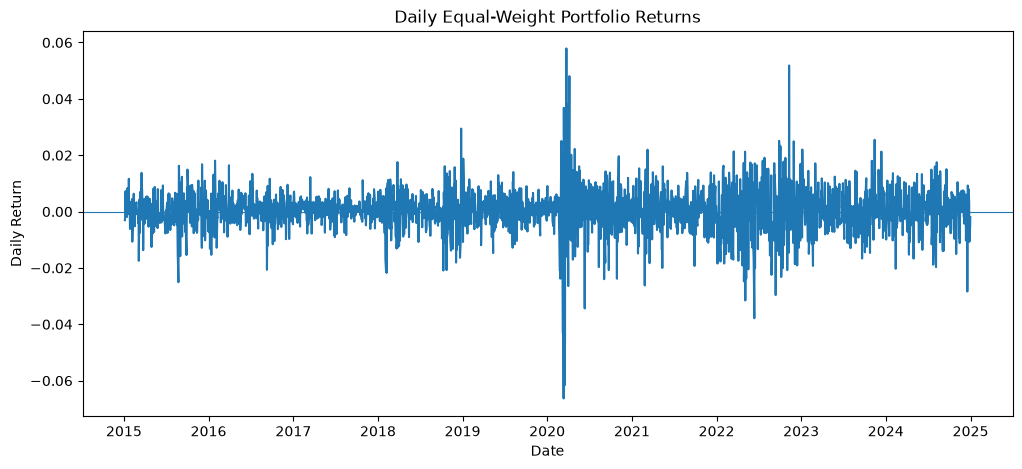

In [155]:
plt.figure(figsize=(12, 5))
plt.plot(portfolio_returns.index, portfolio_returns)
plt.axhline(0, linewidth=0.8)
plt.title("Daily Equal-Weight Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

Daily portfolio returns remain centered near zero, but the magnitude of those returns varies noticeably across the sample. Some periods are relatively stable, while others contain clusters of much larger positive and negative movements. This indicates that volatility is not constant over time.

The most pronounced increase in volatility occurs around 2020, consistent with the COVID-19 market shock and the unusually high level of financial uncertainty during that period. Other parts of the sample also show elevated volatility and isolated extreme returns, indicating that portfolio risk can increase substantially during periods of economic or market stress.

This pattern suggests that using a single constant volatility estimate for the entire sample may be too restrictive. It provides motivation for later comparing constant-volatility models with a time-varying volatility model such as GARCH.

### Rolling Volatility

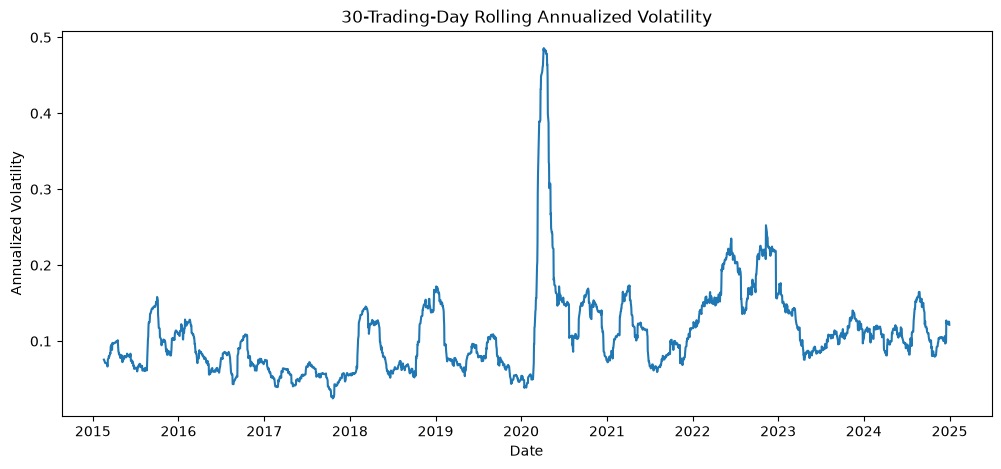

In [156]:
rolling_volatility = portfolio_returns.rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(12, 5))
plt.plot(rolling_volatility.index, rolling_volatility)
plt.title("30-Trading-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.show()

The 30-trading-day rolling volatility estimate shows that portfolio risk changes substantially over time rather than remaining near the full-sample annualized volatility of 12.42%. Volatility is relatively low during calmer periods but rises sharply during periods of market stress, with the largest increase occurring around the 2020 COVID-19 market shock.

The persistence of elevated volatility across consecutive periods also provides evidence of volatility clustering. This suggests that models assuming constant volatility may miss an important feature of the return series and motivates the later use of a time-varying volatility model such as GARCH.

### Distribution of Portfolio Returns

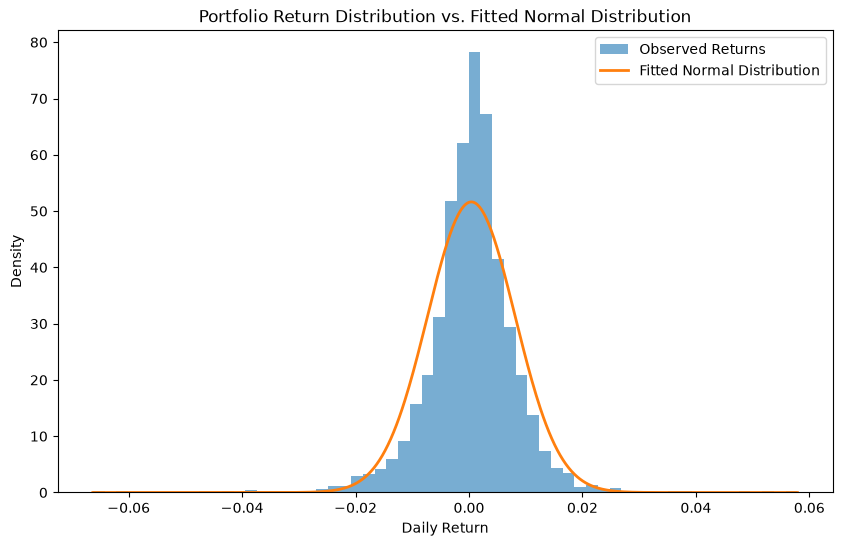

In [157]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

x = np.linspace(
    portfolio_returns.min(),
    portfolio_returns.max(),
    500
)

plt.figure(figsize=(10, 6))
plt.hist(
    portfolio_returns,
    bins=60,
    density=True,
    alpha=0.6,
    label="Observed Returns"
)

plt.plot(
    x,
    stats.norm.pdf(x, loc=mu, scale=sigma),
    linewidth=2,
    label="Fitted Normal Distribution"
)

plt.title("Portfolio Return Distribution vs. Fitted Normal Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.show()


The observed return distribution is centered close to zero and is broadly bell-shaped, but it differs noticeably from the fitted Normal distribution. Returns are more concentrated around the center than the Normal model predicts, while the distribution also contains more extreme observations in the tails.

The distribution shows a slight left skew, consistent with the negative skewness found in the summary statistics, but the larger difference from normality is the combination of a sharper central peak and heavier tails. This supports the earlier finding of high excess kurtosis and suggests that a Gaussian model may underestimate the probability of unusually large gains or losses.

Because tail behavior is especially important for risk measures such as Value-at-Risk and Expected Shortfall, this provides a clear reason to compare the Normal model with heavier-tailed and empirical alternatives.

### Normal Q-Q Plot of Portfolio Returns

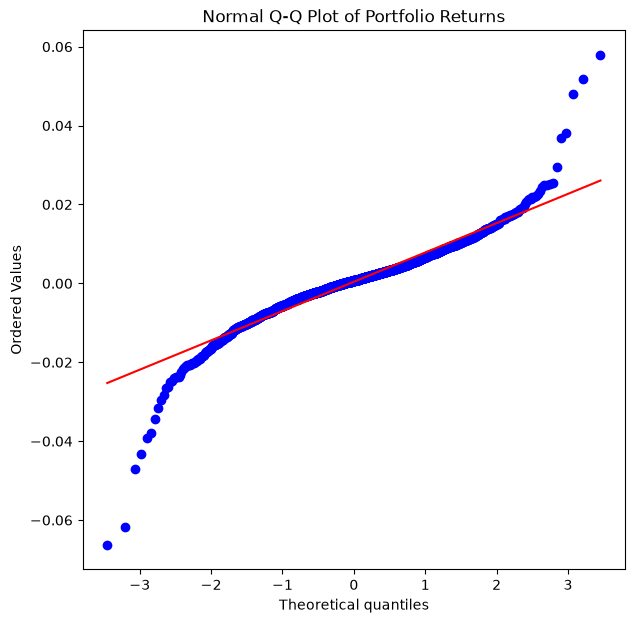

In [158]:
plt.figure(figsize=(7, 7))

stats.probplot(
    portfolio_returns,
    dist="norm",
    plot=plt
)

plt.title("Normal Q-Q Plot of Portfolio Returns")
plt.show()

In [159]:
tail_quantiles = pd.DataFrame({
    "Quantile": ["1%", "5%", "25%", "50%", "75%", "95%", "99%"],
    "Portfolio Return": [
        portfolio_returns.quantile(0.01),
        portfolio_returns.quantile(0.05),
        portfolio_returns.quantile(0.25),
        portfolio_returns.quantile(0.50),
        portfolio_returns.quantile(0.75),
        portfolio_returns.quantile(0.95),
        portfolio_returns.quantile(0.99)
    ]
})

tail_quantiles["Portfolio Return"] = tail_quantiles["Portfolio Return"].map(
    lambda x: f"{x:.2%}"
)

tail_quantiles

,Quantile,Portfolio Return
0,1%,-2.08%
1,5%,-1.14%
2,25%,-0.32%
3,50%,0.07%
4,75%,0.43%
5,95%,1.15%
6,99%,1.84%


The Q-Q plot shows that the middle portion of the return distribution follows the Normal reference line fairly closely, but the tails depart strongly from it. The lowest quantiles contain substantially more negative returns than a Normal distribution would predict, while the highest quantiles contain substantially larger positive returns.

These deviations indicate heavy tails, with several extreme observations occurring far beyond the range implied by the fitted Normal distribution. The fact that both tails bend away from the reference line supports the earlier excess-kurtosis result and suggests that a Gaussian model may underestimate the likelihood of large daily gains and losses.

The lower tail is especially important for the later risk analysis because Value-at-Risk and Expected Shortfall are designed to measure unusually large losses.

The empirical quantiles provide a more direct view of the portfolio's tail behavior. The bottom 5% of daily returns fall below -1.14%, while the bottom 1% fall below -2.08%. On the upper side, the 95th and 99th percentiles are 1.15% and 1.84%, respectively.

The slightly larger magnitude of the lower 1% quantile compared with the upper 99% quantile is consistent with the portfolio's mild negative skewness. These empirical tail thresholds also provide a useful benchmark for the later Value-at-Risk analysis, where model-based estimates can be compared against the observed return distribution.

### Daily Return Correlations

In [160]:
correlation_matrix = returns[tickers].corr()

correlation_matrix

Ticker,SPY,QQQ,IWM,TLT,GLD
Ticker,,,,,
SPY,1.000000,0.929275,0.866513,-0.210155,0.046813
QQQ,0.929275,1.000000,0.762894,-0.146188,0.056423
IWM,0.866513,0.762894,1.000000,-0.185778,0.045783
TLT,-0.210155,-0.146188,-0.185778,1.000000,0.312262
GLD,0.046813,0.056423,0.045783,0.312262,1.000000


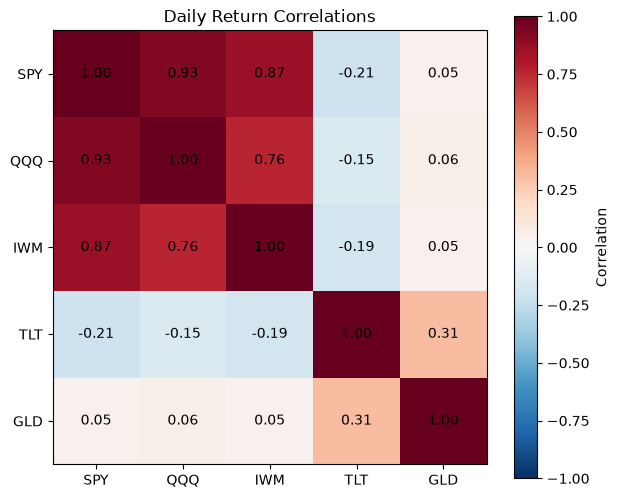

In [161]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    correlation_matrix,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1)

ax.set_xticks(range(len(tickers)))
ax.set_xticklabels(tickers)

ax.set_yticks(range(len(tickers)))
ax.set_yticklabels(tickers)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(image, label="Correlation")
plt.title("Daily Return Correlations")
plt.show()

The three equity ETFs are strongly positively correlated. SPY and QQQ have the highest correlation at 0.93, followed by SPY and IWM at 0.87 and QQQ and IWM at 0.76. This is expected because all three represent different segments of the U.S. equity market and therefore respond to many of the same market movements.

TLT has a small negative correlation with each equity ETF, ranging from approximately -0.15 to -0.21. GLD has correlations close to zero with SPY, QQQ, and IWM, while its correlation with TLT is weakly positive at 0.31. These lower correlations help explain why including Treasury bonds and gold provides diversification relative to a portfolio made up only of equity ETFs.

Overall, the portfolio contains both highly correlated equity exposures and assets that behave more independently, allowing the risk analysis to reflect the effects of diversification across different asset types.

## Static Risk Models

To establish baseline estimates of downside risk, returns are modeled using three static distributional approaches: the Normal distribution, the Student-$t$ distribution, and historical resampling. These models assume the return distribution is constant over time and provide a benchmark for later comparison with the time-varying GARCH model. For each approach, the fitted distribution and implied tail behavior are examined before using the models for Monte Carlo estimation of Value at Risk and Expected Shortfall.

### Normal Distribution

The Normal model assumes daily returns are independently drawn from a Gaussian distribution with constant mean and volatility. The model parameters are estimated directly from the historical return series.

In [162]:
portfolio_returns = returns["Portfolio"].dropna()

mu_normal = portfolio_returns.mean()
sigma_normal = portfolio_returns.std(ddof=1)

print(f"Estimated mean: {mu_normal:.6f}")
print(f"Estimated volatility: {sigma_normal:.6f}")

Estimated mean: 0.000409
Estimated volatility: 0.007727


The fitted Normal model estimates an average daily portfolio return of approximately 0.041% and daily volatility of approximately 0.773%.

### Student-t Distribution

Because the exploratory analysis showed heavier tails than would be expected under a Normal distribution, a Student-$t$ distribution is fitted as an alternative parametric model. Its degrees-of-freedom parameter allows for greater probability in the tails while still estimating the location and scale of the observed portfolio returns.

In [163]:
df_t, loc_t, scale_t = stats.t.fit(portfolio_returns)

sigma_t = scale_t * np.sqrt(df_t / (df_t - 2))

print(f"Degrees of freedom: {df_t:.2f}")
print(f"Location: {loc_t:.6f}")
print(f"Scale: {scale_t:.6f}")
print(f"Implied volatility: {sigma_t:.6f}")

Degrees of freedom: 3.47
Location: 0.000646
Scale: 0.005154
Implied volatility: 0.007920


The fitted Student-$t$ distribution has approximately 3.47 degrees of freedom, indicating substantially heavier tails than a Normal distribution. Its implied daily volatility is approximately 0.792%, slightly above the Normal model estimate of 0.773%, while the fitted location remains close to the historical mean. The low degrees of freedom suggests that the Student-$t$ model is better suited to representing the extreme return behavior observed during the exploratory analysis.

A skewed Student-$t$ specification was also considered to account explicitly for return asymmetry. However, its AIC was higher than that of the symmetric Student-$t$ model (-17809.38 versus -17821.89), indicating that the additional skewness parameter did not provide sufficient improvement in fit to justify the added complexity. The symmetric Student-$t$ model was therefore retained for subsequent simulation.

### Historical Bootstrap

The historical bootstrap provides a nonparametric alternative that avoids imposing a specific probability distribution on returns. Instead, simulated returns are generated by sampling with replacement directly from the observed portfolio return series, preserving the empirical shape, skewness, and tail behavior present in the historical data.

In [164]:
historical_mean = portfolio_returns.mean()
historical_volatility = portfolio_returns.std(ddof=1)

print(f"Historical mean: {historical_mean:.6f}")
print(f"Historical volatility: {historical_volatility:.6f}")
print(f"Number of observations: {len(portfolio_returns)}")

Historical mean: 0.000409
Historical volatility: 0.007727
Number of observations: 2515


Unlike the parametric models, the historical bootstrap uses the observed returns themselves rather than estimating a theoretical distribution. This preserves the empirical heavy tails and asymmetry of the portfolio return distribution and provides a useful benchmark for assessing how much the parametric assumptions affect later risk estimates.

## Monte Carlo Simulation

Monte Carlo simulation is used to estimate the portfolio's downside risk under each static return model. A large number of one-day portfolio returns are generated from the fitted Normal distribution, fitted Student-$t$ distribution, and historical bootstrap. The simulated return distributions are then used to estimate Value at Risk (VaR) and Expected Shortfall (ES) at the 95% and 99% confidence levels.

In [165]:
n_simulations = 100_000
rng = np.random.default_rng(42)

# Normal model
sim_normal = rng.normal(
    loc=mu_normal,
    scale=sigma_normal,
    size=n_simulations
)

# Student-t model
sim_t = stats.t.rvs(
    df=df_t,
    loc=loc_t,
    scale=scale_t,
    size=n_simulations,
    random_state=rng
)

# Historical bootstrap
sim_historical = rng.choice(
    portfolio_returns.to_numpy(),
    size=n_simulations,
    replace=True
)

print(f"Simulations per model: {n_simulations:,}")

Simulations per model: 100,000


In [166]:
def calculate_var_es(simulated_returns, confidence):
    alpha = 1 - confidence
    
    cutoff = np.quantile(simulated_returns, alpha)
    
    var = -cutoff
    es = -simulated_returns[simulated_returns <= cutoff].mean()
    
    return var, es

In [167]:
models = {
    "Normal": sim_normal,
    "Student-t": sim_t,
    "Historical Bootstrap": sim_historical
}

results = []

for model_name, simulated_returns in models.items():
    var_95, es_95 = calculate_var_es(simulated_returns, 0.95)
    var_99, es_99 = calculate_var_es(simulated_returns, 0.99)
    
    results.append({
        "Model": model_name,
        "95% VaR": var_95,
        "95% ES": es_95,
        "99% VaR": var_99,
        "99% ES": es_99
    })

risk_results = pd.DataFrame(results)
risk_results_percent = risk_results.copy()

for col in ["95% VaR", "95% ES", "99% VaR", "99% ES"]:
    risk_results_percent[col] = (
        risk_results_percent[col] * 100
    ).round(3)

risk_results_percent

,Model,95% VaR,95% ES,99% VaR,99% ES
0,Normal,1.240,1.561,1.770,2.036
1,Student-t,1.083,1.723,2.017,2.976
2,Historical Bootstrap,1.140,1.820,2.077,3.037


Value at Risk (VaR) represents the loss threshold that is exceeded only in the worst 5% or 1% of simulated outcomes at the 95% and 99% confidence levels, respectively. The models produce similar risk estimates at the 95% level, but the differences become larger in the most extreme part of the return distribution. The Normal model gives a 95% VaR of about 1.24%, compared with 1.08% for the Student-$t$ model and 1.14% for the historical bootstrap. At the 99% level, however, the Student-$t$ and historical models produce larger VaR estimates of about 2.02% and 2.08%, compared with 1.77% under the Normal model.

The same pattern is stronger for Expected Shortfall, which measures the average loss among returns that fall beyond the VaR cutoff. At the 99% level, Expected Shortfall is about 2.04% under the Normal model, 2.98% under the Student-$t$ model, and 3.04% under the historical bootstrap. Relative to the Normal model, the 99% Expected Shortfall is approximately 46.2% higher under the Student-$t$ model and 49.2% higher under the historical bootstrap.

The plot makes this difference especially clear at the 99% level. While the three models are relatively close for 95% VaR, the gap widens for 99% VaR and becomes largest for 99% Expected Shortfall. The Student-$t$ and historical bootstrap give similar estimates in the extreme tail, while the Normal model remains noticeably lower. This suggests that the Normal assumption captures moderate downside risk reasonably well but gives less conservative estimates of severe one-day losses.

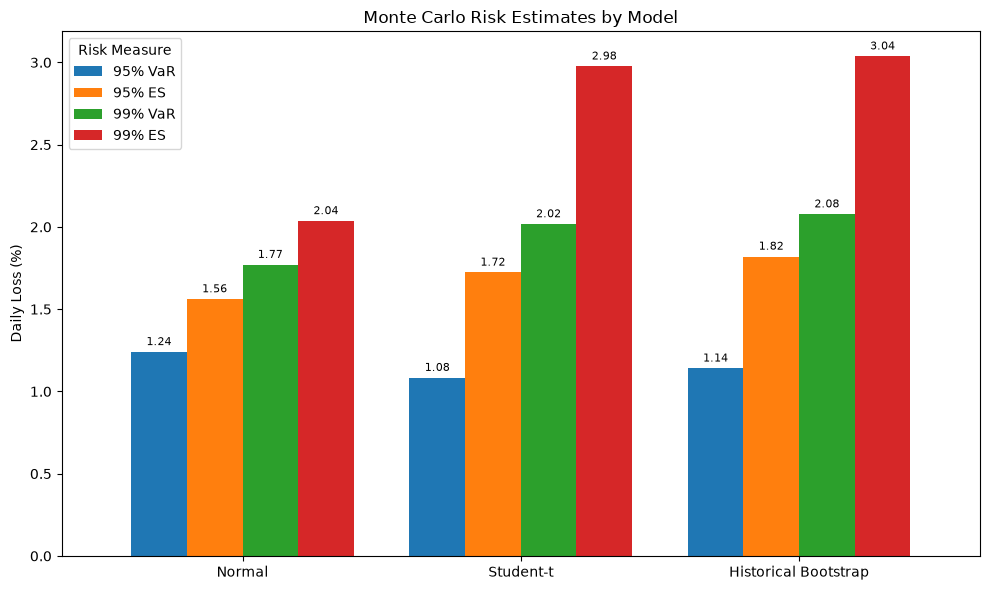

In [168]:
risk_plot = risk_results_percent.set_index("Model")

ax = risk_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

ax.set_title("Monte Carlo Risk Estimates by Model")
ax.set_xlabel("")
ax.set_ylabel("Daily Loss (%)")
ax.legend(title="Risk Measure")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The figure compares the 95% and 99% VaR and Expected Shortfall estimates across the three simulation models. Differences between the models are relatively small at the 95% VaR level but become more pronounced for the 99% measures, particularly Expected Shortfall. The Student-$t$ and historical bootstrap produce similar estimates in the far tail, while the Normal model gives consistently lower estimates of extreme-loss severity.

## GARCH(1,1)

The static risk models assume that return volatility is constant over time. To account for volatility clustering, a GARCH(1,1) model is fitted to the portfolio return series. The model allows conditional volatility to change over time based on recent squared return shocks and past volatility, providing a dynamic estimate of portfolio risk.

In [197]:
from arch import arch_model

garch_normal = arch_model(
    garch_returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_normal_fit = garch_normal.fit(disp="off")

garch_model = arch_model(
    garch_returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_fit = garch_model.fit(disp="off")

In [198]:
garch_comparison = pd.DataFrame({
    "Model": ["GARCH-Normal", "GARCH-Student-t"],
    "AIC": [garch_normal_fit.aic, garch_fit.aic],
    "BIC": [garch_normal_fit.bic, garch_fit.bic]
})

garch_comparison

,Model,AIC,BIC
0,GARCH-Normal,4954.528228,4977.848340
1,GARCH-Student-t,4859.984978,4889.135119


The GARCH(1,1) model was fitted with both Normal and Student-$t$ return shocks. The Student-$t$ specification produced substantially lower AIC and BIC values (4859.98 and 4889.14) than the Normal specification (4954.53 and 4977.85). This indicates that allowing for heavier-tailed shocks provides a considerably better fit, so the GARCH-Student-$t$ model is retained for the remaining analysis.

In [199]:
garch_returns = portfolio_returns * 100
print(garch_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                    Portfolio   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2424.99
Distribution:      Standardized Student's t   AIC:                           4859.98
Method:                  Maximum Likelihood   BIC:                           4889.14
                                              No. Observations:                 2515
Date:                      Sun, Sep 13 2026   Df Residuals:                     2514
Time:                              22:22:50   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

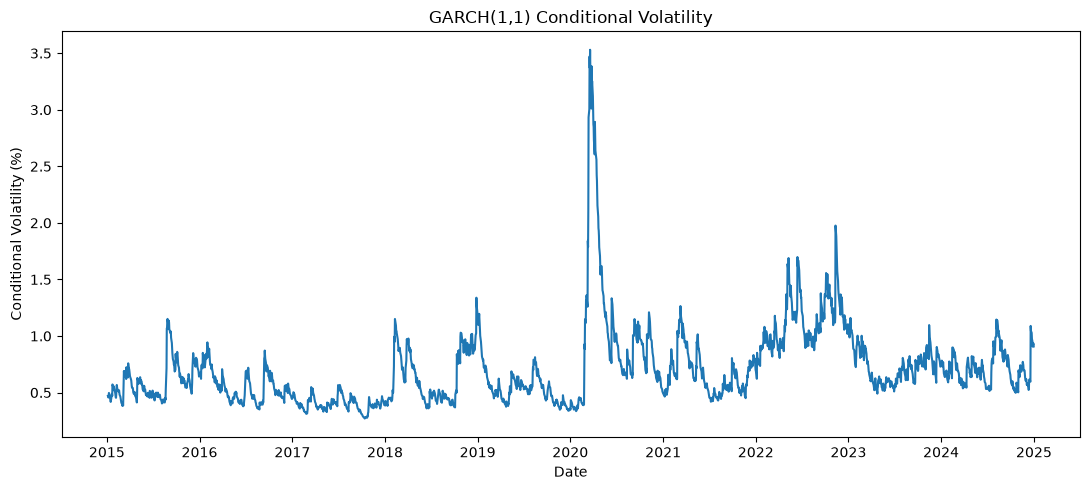

In [200]:
conditional_volatility = garch_fit.conditional_volatility

plt.figure(figsize=(11, 5))
plt.plot(conditional_volatility)

plt.title("GARCH(1,1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Conditional Volatility (%)")

plt.tight_layout()
plt.show()

The GARCH(1,1) model estimates current volatility using three components: a baseline variance level, the size of the most recent return shock, and the previous period's estimated volatility. The estimated shock coefficient is $\alpha_1=0.102$, meaning that unusually large recent returns increase the model's volatility estimate. The persistence coefficient is much larger at $\beta_1=0.893$, showing that once volatility becomes elevated, it tends to remain elevated rather than immediately returning to its long-run level.

Together, $\alpha_1+\beta_1\approx0.995$. Because this value is very close to one, volatility shocks fade slowly. In practical terms, a large market move can continue to affect the model's risk estimate for many subsequent trading days.

The fitted Student-$t$ distribution has approximately 7.16 degrees of freedom. This relatively low value indicates that, even after accounting for changes in volatility over time, unusually large return shocks occur more often than they would under a Normal distribution.

The conditional volatility plot shows how the GARCH estimate changes through time. During calmer periods, estimated daily volatility is generally below 1%, while major stress periods produce sharp increases. The largest spike occurs around 2020, reaching roughly 3.6% per day, followed by a gradual decline rather than an immediate return to normal levels. This gradual decline is consistent with the high persistence estimated by the model.

This differs from the 30-day rolling volatility measure used in the exploratory analysis. Rolling volatility simply calculates the standard deviation of the previous 30 days, while GARCH updates volatility using the size of recent shocks and the model's previous volatility estimate. As a result, GARCH provides a time-varying model of volatility that can also be used to forecast future risk.

### Dynamic VaR and Expected Shortfall

The fitted GARCH-Student-$t$ model is used to generate time-varying one-day risk estimates. Unlike the static models, which apply one return distribution to the full sample, GARCH updates the conditional volatility each day. VaR and Expected Shortfall therefore rise during high-volatility periods and fall during calmer periods.

In [201]:
from scipy.stats import t

mu_garch = garch_fit.params["mu"]
nu_garch = garch_fit.params["nu"]
sigma_garch = garch_fit.conditional_volatility

# arch uses standardized Student-t innovations
q95 = t.ppf(0.05, df=nu_garch) * np.sqrt((nu_garch - 2) / nu_garch)
q99 = t.ppf(0.01, df=nu_garch) * np.sqrt((nu_garch - 2) / nu_garch)

garch_var_95 = -(mu_garch + sigma_garch * q95)
garch_var_99 = -(mu_garch + sigma_garch * q99)

In [202]:
def standardized_t_es(alpha, nu):
    q = t.ppf(alpha, df=nu)

    # Positive magnitude of the expected loss in the left tail
    es = (
        t.pdf(q, df=nu)
        * (nu + q**2)
        / ((nu - 1) * alpha)
    )

    return es * np.sqrt((nu - 2) / nu)


es_factor_95 = standardized_t_es(0.05, nu_garch)
es_factor_99 = standardized_t_es(0.01, nu_garch)

garch_es_95 = -mu_garch + sigma_garch * es_factor_95
garch_es_99 = -mu_garch + sigma_garch * es_factor_99

In [203]:
garch_risk = pd.DataFrame({
    "VaR 95%": garch_var_95,
    "ES 95%": garch_es_95,
    "VaR 99%": garch_var_99,
    "ES 99%": garch_es_99
})

garch_risk.head()

,VaR 95%,ES 95%,VaR 99%,ES 99%
Date,,,,
2015-01-05,0.688738,0.965135,1.124723,1.427395
2015-01-06,0.682074,0.956028,1.114207,1.414205
2015-01-07,0.665351,0.933180,1.087821,1.381110
2015-01-08,0.686472,0.962039,1.121147,1.422910
2015-01-09,0.731253,1.023226,1.191807,1.511536


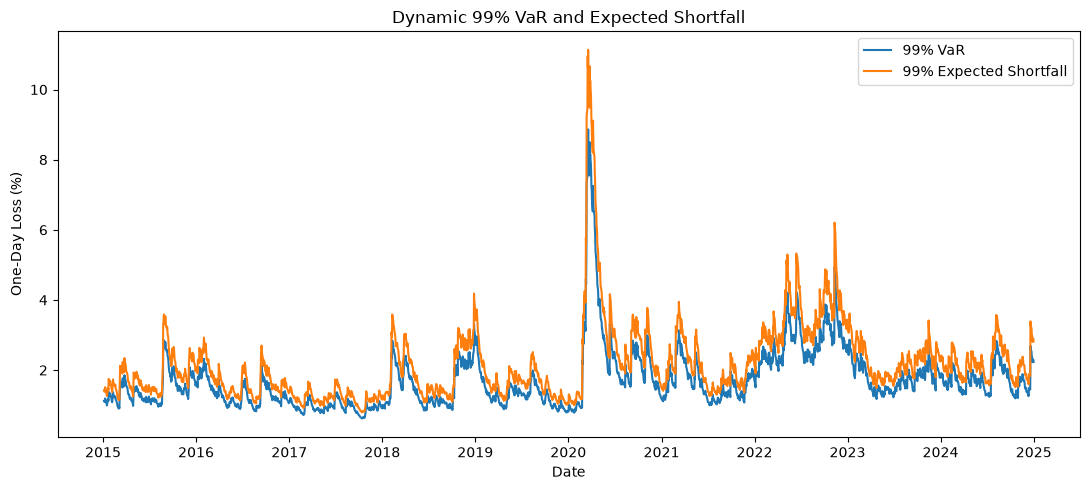

In [204]:
plt.figure(figsize=(11, 5))

plt.plot(
    garch_risk.index,
    garch_risk["VaR 99%"],
    label="99% VaR"
)

plt.plot(
    garch_risk.index,
    garch_risk["ES 99%"],
    label="99% Expected Shortfall"
)

plt.title("Dynamic 99% VaR and Expected Shortfall")
plt.xlabel("Date")
plt.ylabel("One-Day Loss (%)")
plt.legend()

plt.tight_layout()
plt.show()

In [205]:
garch_average = pd.DataFrame({
    "Model": ["GARCH-Student-t"],
    "95% VaR": [garch_var_95.mean()],
    "95% ES": [garch_es_95.mean()],
    "99% VaR": [garch_var_99.mean()],
    "99% ES": [garch_es_99.mean()]
})

garch_average[["95% VaR", "95% ES", "99% VaR", "99% ES"]] = (
    garch_average[["95% VaR", "95% ES", "99% VaR", "99% ES"]].round(3)
)

risk_comparison = pd.concat(
    [risk_results_percent, garch_average],
    ignore_index=True
)

risk_comparison

,Model,95% VaR,95% ES,99% VaR,99% ES
0,Normal,1.240,1.561,1.770,2.036
1,Student-t,1.083,1.723,2.017,2.976
2,Historical Bootstrap,1.140,1.820,2.077,3.037
3,GARCH-Student-t,1.066,1.481,1.720,2.174


As seen in the graph, the dynamic GARCH risk estimates vary substantially over time rather than remaining fixed at a single level. During calmer periods, the 99% VaR generally stays near 1–2%, while periods of market stress produce much larger estimates. The largest increase occurs around 2020, when the one-day 99% VaR rises to roughly 9% and the corresponding Expected Shortfall exceeds 11%. Expected Shortfall remains above VaR throughout the sample because it measures the average loss conditional on already being in the worst 1% of outcomes.

The average GARCH-Student-$t$ estimates are 1.07% for 95% VaR and 1.48% for 95% Expected Shortfall, compared with 1.72% and 2.17% at the 99% level. At the 95% level, the GARCH estimates are slightly lower than the corresponding static-model estimates. At the 99% level, the gap is larger relative to the static Student-$t$ and historical bootstrap models. However, this does not mean that GARCH consistently estimates less risk. Instead, the GARCH model produces lower estimates during calm periods and much higher estimates during volatility spikes. The static models apply the same risk level across the full sample, while GARCH adjusts the estimated loss threshold as market conditions change.

This distinction is important because the table summarizes only the average level of GARCH risk. The time-series plot shows that the main benefit of the model is its ability to respond to changing volatility, particularly during periods when fixed static estimates would fail to reflect rapidly increasing market risk.

## Out-of-Sample Backtesting

To evaluate how well the risk models perform on unseen data, one-day VaR forecasts are backtested against realized portfolio returns. Model accuracy is assessed using the frequency of VaR breaches and formal coverage tests. A well-calibrated 95% VaR model should be exceeded on approximately 5% of days, while a 99% VaR model should be exceeded on approximately 1% of days.

In [ ]:
# Build out-of-sample portfolio returns

combined_prices = pd.concat([
    train_prices.iloc[[-1]],
    test_prices
])

test_asset_returns = combined_prices.pct_change().dropna()

test_asset_returns["Portfolio"] = (
    test_asset_returns[tickers] @ weights
)

test_portfolio_returns = test_asset_returns["Portfolio"]
print(f"Training observations: {len(portfolio_returns)}")
print(f"Test observations: {len(test_portfolio_returns)}")
print(f"Test period: {test_portfolio_returns.index.min().date()} to "
      f"{test_portfolio_returns.index.max().date()}")

Training observations: 2515
Test observations: 424
Test period: 2025-01-02 to 2026-09-11


In [207]:
from scipy.stats import norm, t
from arch import arch_model

forecast_rows = []

history = portfolio_returns.copy()

for date, realized_return in test_portfolio_returns.items():

    # Work in percentage returns for consistency
    history_pct = history * 100

    # -----------------------
    # Normal VaR
    # -----------------------
    mu = history_pct.mean()
    sigma = history_pct.std(ddof=1)

    normal_var_95 = -(mu + sigma * norm.ppf(0.05))
    normal_var_99 = -(mu + sigma * norm.ppf(0.01))

    # -----------------------
    # Student-t VaR
    # -----------------------
    df_t_bt, loc_t_bt, scale_t_bt = t.fit(history_pct)

    student_var_95 = -t.ppf(
        0.05,
        df=df_t_bt,
        loc=loc_t_bt,
        scale=scale_t_bt
    )

    student_var_99 = -t.ppf(
        0.01,
        df=df_t_bt,
        loc=loc_t_bt,
        scale=scale_t_bt
    )

    # -----------------------
    # Historical VaR
    # -----------------------
    historical_var_95 = -np.quantile(history_pct, 0.05)
    historical_var_99 = -np.quantile(history_pct, 0.01)

    # -----------------------
    # GARCH-Student-t VaR
    # -----------------------
    garch_bt = arch_model(
        history_pct,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    garch_bt_fit = garch_bt.fit(
        disp="off",
        show_warning=False
    )

    forecast = garch_bt_fit.forecast(horizon=1)

    mu_garch_bt = garch_bt_fit.params["mu"]
    nu_garch_bt = garch_bt_fit.params["nu"]

    sigma_forecast = np.sqrt(
        forecast.variance.iloc[-1, 0]
    )

    # arch uses variance-standardized Student-t shocks
    q95 = (
        t.ppf(0.05, df=nu_garch_bt)
        * np.sqrt((nu_garch_bt - 2) / nu_garch_bt)
    )

    q99 = (
        t.ppf(0.01, df=nu_garch_bt)
        * np.sqrt((nu_garch_bt - 2) / nu_garch_bt)
    )

    garch_var_95 = -(
        mu_garch_bt + sigma_forecast * q95
    )

    garch_var_99 = -(
        mu_garch_bt + sigma_forecast * q99
    )

    # Save forecast and realized return
    forecast_rows.append({
        "Date": date,
        "Realized Return": realized_return * 100,

        "Normal 95% VaR": normal_var_95,
        "Normal 99% VaR": normal_var_99,

        "Student-t 95% VaR": student_var_95,
        "Student-t 99% VaR": student_var_99,

        "Historical 95% VaR": historical_var_95,
        "Historical 99% VaR": historical_var_99,

        "GARCH-t 95% VaR": garch_var_95,
        "GARCH-t 99% VaR": garch_var_99
    })

    # Only after forecasting do we reveal today's return
    history = pd.concat([
        history,
        pd.Series(
            [realized_return],
            index=[date]
        )
    ])

In [208]:
backtest = pd.DataFrame(forecast_rows).set_index("Date")

backtest.head()

,Realized Return,Normal 95% VaR,Normal 99% VaR,Student-t 95% VaR,Student-t 99% VaR,Historical 95% VaR,Historical 99% VaR,GARCH-t 95% VaR,GARCH-t 99% VaR
Date,,,,,,,,,
2025-01-02,0.254744,1.229958,1.756515,1.084229,2.040604,1.141850,2.076751,1.321190,2.122668
2025-01-03,0.653697,1.229640,1.756100,1.083810,2.040412,1.141828,2.076739,1.253337,2.015955
2025-01-06,0.239090,1.229303,1.755724,1.083474,2.039399,1.141805,2.076727,1.222035,1.966503
2025-01-07,-0.856194,1.228988,1.755312,1.083062,2.039242,1.141783,2.076715,1.159805,1.868620
2025-01-08,0.073946,1.229433,1.755793,1.083705,2.038906,1.141760,2.076702,1.191314,1.917598


In [209]:
models = [
    "Normal",
    "Student-t",
    "Historical",
    "GARCH-t"
]

for model in models:
    backtest[f"{model} 95% Breach"] = (
        backtest["Realized Return"]
        < -backtest[f"{model} 95% VaR"]
    )

    backtest[f"{model} 99% Breach"] = (
        backtest["Realized Return"]
        < -backtest[f"{model} 99% VaR"]
    )

### VaR Breach Rates

In [210]:
breach_results = []

for model in models:
    breach_95 = backtest[f"{model} 95% Breach"]
    breach_99 = backtest[f"{model} 99% Breach"]

    breach_results.append({
        "Model": model,
        "95% Breaches": breach_95.sum(),
        "95% Breach Rate": breach_95.mean() * 100,
        "99% Breaches": breach_99.sum(),
        "99% Breach Rate": breach_99.mean() * 100
    })

breach_table = pd.DataFrame(breach_results)

breach_table[
    ["95% Breach Rate", "99% Breach Rate"]
] = breach_table[
    ["95% Breach Rate", "99% Breach Rate"]
].round(2)

breach_table

,Model,95% Breaches,95% Breach Rate,99% Breaches,99% Breach Rate
0,Normal,26,6.13,10,2.36
1,Student-t,34,8.02,7,1.65
2,Historical,29,6.84,7,1.65
3,GARCH-t,28,6.60,7,1.65


The observed breach frequencies provide an initial measure of model calibration. A correctly specified 95% VaR model should produce breaches on approximately 5% of trading days, while a 99% VaR model should produce breaches on approximately 1%.

At the 95% confidence level, the Normal model produced the lowest breach rate at 6.13%, followed by GARCH-t at 6.60%, Historical Simulation at 6.84%, and Student-t at 8.02%. All models therefore experienced more losses beyond VaR than the nominal 5% rate, indicating some degree of risk underestimation, with the Student-t model showing the largest discrepancy.

At the 99% level, the Normal model produced a breach rate of 2.36%, while the Student-t, Historical, and GARCH-t models each produced a breach rate of 1.65%. Although all exceeded the nominal 1% rate, the heavy-tailed and historical approaches were substantially closer to the target than the Normal model.

Student-t, Historical Simulation, and GARCH-t each recorded exactly seven 99% VaR breaches, so their later 99% coverage statistics are expected to be identical or nearly identical, particularly if the violations occurred on the same extreme-loss days. This similarity is unsurprising at the 99% confidence level, where tail observations are rare and only a small number of realized losses are severe enough to generate breaches.

### Kupiec Unconditional Coverage Test

In [212]:
from scipy.stats import chi2

def kupiec_test(breaches, expected_rate):
    breaches = np.asarray(breaches, dtype=int)

    n = len(breaches)
    x = breaches.sum()

    observed_rate = x / n

    # Avoid log(0)
    eps = 1e-12
    observed_rate = np.clip(observed_rate, eps, 1 - eps)
    expected_rate = np.clip(expected_rate, eps, 1 - eps)

    log_likelihood_null = (
        (n - x) * np.log(1 - expected_rate)
        + x * np.log(expected_rate)
    )

    log_likelihood_alt = (
        (n - x) * np.log(1 - observed_rate)
        + x * np.log(observed_rate)
    )

    lr_uc = -2 * (
        log_likelihood_null - log_likelihood_alt
    )

    p_value = 1 - chi2.cdf(lr_uc, df=1)

    return lr_uc, p_value

In [213]:
kupiec_results = []

for model in models:
    lr_95, p_95 = kupiec_test(
        backtest[f"{model} 95% Breach"],
        expected_rate=0.05
    )

    lr_99, p_99 = kupiec_test(
        backtest[f"{model} 99% Breach"],
        expected_rate=0.01
    )

    kupiec_results.append({
        "Model": model,
        "95% Kupiec LR": lr_95,
        "95% p-value": p_95,
        "99% Kupiec LR": lr_99,
        "99% p-value": p_99
    })

kupiec_table = pd.DataFrame(kupiec_results)

kupiec_table.round(4)

,Model,95% Kupiec LR,95% p-value,99% Kupiec LR,99% p-value
0,Normal,1.0704,0.3009,5.7198,0.0168
1,Student-t,6.9316,0.0085,1.5170,0.2181
2,Historical,2.7231,0.0989,1.5170,0.2181
3,GARCH-t,2.0948,0.1478,1.5170,0.2181


The Kupiec test evaluates whether the observed proportion of VaR breaches is statistically consistent with the model's nominal coverage rate. The null hypothesis is that the model has the correct unconditional breach probability; therefore, a p-value above 0.05 indicates that the model is not rejected at the 5% significance level.

For 95% VaR, the Normal, Historical, and GARCH-t models were not rejected at the 5% significance level, with p-values of 0.3009, 0.0989, and 0.1478, respectively. Historical Simulation lies relatively close to the rejection threshold and would be rejected under a 10% significance threshold, while the Normal and GARCH-t models provide stronger evidence of acceptable unconditional coverage. The Student-t model was clearly rejected with a p-value of 0.0085, consistent with its relatively high 8.02% breach rate.

At the 99% level, the result reversed for the Normal model. Its p-value of 0.0168 indicates significantly too many tail breaches relative to the expected 1% rate. In contrast, Student-t, Historical, and GARCH-t each recorded seven breaches and therefore produced identical Kupiec statistics and p-values of 0.2181, which were not rejected. Because the Kupiec test depends only on the total number of violations, models with the same breach count receive the same unconditional coverage result, even if their underlying VaR forecasts differ.

These results suggest that the non-Normal models provided better calibration for extreme tail risk.

### Christoffersen Independence Test

In [214]:
def christoffersen_independence_test(breaches):
    breaches = np.asarray(breaches, dtype=int)

    previous = breaches[:-1]
    current = breaches[1:]

    n00 = np.sum((previous == 0) & (current == 0))
    n01 = np.sum((previous == 0) & (current == 1))
    n10 = np.sum((previous == 1) & (current == 0))
    n11 = np.sum((previous == 1) & (current == 1))

    eps = 1e-12

    pi01 = n01 / max(n00 + n01, 1)
    pi11 = n11 / max(n10 + n11, 1)

    pi = (n01 + n11) / max(
        n00 + n01 + n10 + n11,
        1
    )

    pi01 = np.clip(pi01, eps, 1 - eps)
    pi11 = np.clip(pi11, eps, 1 - eps)
    pi = np.clip(pi, eps, 1 - eps)

    log_likelihood_null = (
        (n00 + n10) * np.log(1 - pi)
        + (n01 + n11) * np.log(pi)
    )

    log_likelihood_alt = (
        n00 * np.log(1 - pi01)
        + n01 * np.log(pi01)
        + n10 * np.log(1 - pi11)
        + n11 * np.log(pi11)
    )

    lr_ind = -2 * (
        log_likelihood_null - log_likelihood_alt
    )

    p_value = 1 - chi2.cdf(lr_ind, df=1)

    return lr_ind, p_value

In [215]:
christoffersen_results = []

for model in models:
    lr_95, p_95 = christoffersen_independence_test(
        backtest[f"{model} 95% Breach"]
    )

    lr_99, p_99 = christoffersen_independence_test(
        backtest[f"{model} 99% Breach"]
    )

    christoffersen_results.append({
        "Model": model,
        "95% Christoffersen LR": lr_95,
        "95% p-value": p_95,
        "99% Christoffersen LR": lr_99,
        "99% p-value": p_99
    })

christoffersen_table = pd.DataFrame(
    christoffersen_results
)

christoffersen_table.round(4)

,Model,95% Christoffersen LR,95% p-value,99% Christoffersen LR,99% p-value
0,Normal,0.2886,0.5911,1.4813,0.2236
1,Student-t,0.0301,0.8623,2.7822,0.0953
2,Historical,0.5243,0.4690,2.7822,0.0953
3,GARCH-t,0.5299,0.4667,2.7822,0.0953


Correct VaR coverage requires not only an appropriate number of breaches, but also that those breaches occur independently through time rather than clustering during particular periods. The Christoffersen independence test evaluates this property, with the null hypothesis that successive VaR violations are independent.

None of the models were rejected at the 5% significance level. At 95% VaR, p-values ranged from 0.4667 to 0.8623, so there is little evidence that breaches were clustered over time. The Student-t model had the highest p-value at 0.8623, while Historical and GARCH-t produced very similar results.

At 99% VaR, the Normal model had a p-value of 0.2236, while Student-t, Historical, and GARCH-t each had a p-value of 0.0953. These three models still pass the test at the 5% level, but the result is much closer to rejection than at 95% VaR. This indicates that the timing of the most extreme breaches is somewhat less consistent with independence, even though the evidence is not strong enough to reject the null at the chosen significance level.

Although the 99% results for Student-t, Historical, and GARCH-t are closer to the rejection threshold, they remain above 0.05. Overall, the independence results indicate that the observed VaR failures were not significantly clustered over the test period.

### Conditional Coverage Test

In [216]:
conditional_results = []

for i, model in enumerate(models):
    for level in ["95%", "99%"]:
        lr_uc = kupiec_table.loc[
            i, f"{level} Kupiec LR"
        ]

        lr_ind = christoffersen_table.loc[
            i, f"{level} Christoffersen LR"
        ]

        lr_cc = lr_uc + lr_ind
        p_value = 1 - chi2.cdf(lr_cc, df=2)

        conditional_results.append({
            "Model": model,
            "Confidence Level": level,
            "Conditional Coverage LR": lr_cc,
            "p-value": p_value
        })

conditional_coverage_table = pd.DataFrame(
    conditional_results
)

conditional_coverage_table.round(4)

,Model,Confidence Level,Conditional Coverage LR,p-value
0,Normal,95%,1.3590,0.5069
1,Normal,99%,7.2012,0.0273
2,Student-t,95%,6.9616,0.0308
3,Student-t,99%,4.2992,0.1165
4,Historical,95%,3.2474,0.1972
5,Historical,99%,4.2992,0.1165
6,GARCH-t,95%,2.6247,0.2692
7,GARCH-t,99%,4.2992,0.1165


The conditional coverage test jointly evaluates both correct breach frequency and independence of violations. A model is therefore not rejected only when its VaR forecasts are sufficiently well calibrated and its breaches do not exhibit statistically significant clustering.

At the 95% confidence level, the Normal, Historical, and GARCH-t models passed the conditional coverage test, with p-values of 0.5069, 0.1972, and 0.2692, respectively. Student-t was rejected with a p-value of 0.0308, driven primarily by its excessive number of 95% VaR breaches.

At the 99% level, the Normal model was rejected with a p-value of 0.0273, reflecting its poor extreme-tail calibration. Student-t, Historical, and GARCH-t all passed with p-values of 0.1165.

Taken together, Historical Simulation and GARCH-t were the only models that passed the Kupiec, independence, and conditional coverage tests at both confidence levels. GARCH-t produced a slightly lower 95% breach rate than Historical Simulation (6.60% versus 6.84%), while both produced identical 99% breach rates of 1.65%. Given its slightly better 95% calibration and its ability to model time-varying volatility explicitly, GARCH-t is the preferred overall specification, while Historical Simulation provides a strong nonparametric benchmark.

## Model Comparison and Final Results

Across the full analysis, the portfolio return distribution showed clear departures from normality. The exploratory analysis indicated heavy tails and a small degree of negative skew, meaning large losses occurred more often than a Normal model would imply. However, the skew was relatively modest. This was also reflected in model selection: adding a skewed innovation (return shocks) distribution did not improve the GARCH specification enough to justify using it, and the skewed-t version produced worse information criteria than the symmetric Student-t alternative. The final GARCH model therefore used Student-t innovations, which captured excess tail risk without adding unnecessary asymmetry.

The Normal and static Student-t models produced a useful trade-off rather than a clear winner. The Normal model was reasonably calibrated at the 95% level but substantially underestimated risk in the 99% tail, where it produced too many breaches and failed both unconditional and conditional coverage tests. The Student-t model showed the opposite pattern: its heavier tails provided better protection against the most extreme losses at the 99% level, but its 95% VaR was too conservative and produced significantly too many breaches relative to the nominal rate. This suggests that a single fixed distribution may struggle to match both moderate and extreme tail behavior simultaneously. At the same time, both models are static and therefore apply a fixed return distribution across the test period rather than adjusting to changes in market volatility. Their opposing calibration errors may therefore reflect not only differences in tail thickness, but also the limitations of modeling tail behavior without allowing conditional volatility to evolve over time.

The contrast also suggests a natural direction for model tuning. Rather than choosing between fully Normal and strongly heavy-tailed assumptions, a validation-based procedure could tune the effective tail thickness of the Student-t distribution, for example through the estimated degrees-of-freedom parameter or through model selection on a separate validation period. This would allow the model to balance the Normal model's stronger 95% calibration against the Student-t model's stronger 99% tail protection before evaluating final performance on a held-out test set.

Historical Simulation performed strongly despite its simplicity. Because it uses the empirical return distribution rather than imposing a parametric shape, it naturally preserved the observed skewness, tail thickness, and other irregularities in the data. This made it well suited to a portfolio whose return distribution was not well described by a Normal model. Historical Simulation passed all three backtesting tests at both confidence levels and produced 99% performance comparable to GARCH-t. Its main limitation is that it treats the historical distribution as representative of current risk conditions and does not explicitly model changing volatility.

GARCH-t provided the strongest overall balance between distributional fit and dynamic risk modeling. The Student-t innovations accounted for the heavy tails observed in the return distribution, while the GARCH structure allowed conditional volatility to change over time. Unlike the static Student-t model, GARCH-t could therefore respond to periods of elevated or reduced market volatility rather than applying one fixed unconditional distribution throughout the sample. It passed the Kupiec, Christoffersen independence, and conditional coverage tests at both the 95% and 99% levels and also produced a slightly lower 95% breach rate than Historical Simulation.

The comparison between Student-t and GARCH-t is particularly important. Both incorporate heavy-tailed innovations, but only GARCH-t models volatility dynamics. The substantially better out-of-sample performance of GARCH-t suggests that time-varying volatility was more important for VaR calibration than heavy tails alone. Similarly, the poor performance of the skewed-t GARCH specification suggests that the small amount of left skew observed in the exploratory analysis did not contain enough additional information to justify adjusting the model for it.

Overall, the results support GARCH-t as the preferred risk model for this portfolio, with Historical Simulation serving as a strong nonparametric benchmark. The Normal model remained adequate for less extreme 95% risk estimation but became unreliable in the 99% tail, while the static Student-t model showed that a theoretically more realistic return distribution does not necessarily produce better VaR forecasts. The strongest models were therefore not simply those with the most flexible distributional assumptions, but those that captured the features of the data that mattered most for forecasting: either the empirical shape of returns directly, as in Historical Simulation, or the combination of heavy tails and changing volatility, as in GARCH-t.

These findings directly answer the central question of how tail risk can be modeled statistically: improving the assumed tail distribution helps, but distributional shape alone is not enough. The strongest out-of-sample performance came from methods that either retained the empirical return distribution or modeled volatility dynamically. In this portfolio, the evidence therefore favors GARCH-t as the most complete specification, with Historical Simulation as a strong benchmark and the Normal-versus-Student-t trade-off showing why tail thickness itself may need to be tuned rather than chosen categorically.


### Portfolio Weighting and Tail Risk

In [217]:
cov_matrix = returns[tickers].cov()

portfolio_var = weights @ cov_matrix.values @ weights
portfolio_vol = np.sqrt(portfolio_var)

marginal_contrib = cov_matrix.values @ weights / portfolio_vol
component_contrib = weights * marginal_contrib

risk_contribution = pd.DataFrame({
    "Asset": tickers,
    "Component Volatility": component_contrib,
    "Percent Contribution": component_contrib / portfolio_vol * 100
})

risk_contribution["Percent Contribution"] = (
    risk_contribution["Percent Contribution"].round(2)
)

risk_contribution

,Asset,Component Volatility,Percent Contribution
0,SPY,0.001985,25.69
1,QQQ,0.002417,31.28
2,IWM,0.002414,31.25
3,TLT,0.000272,3.52
4,GLD,0.000638,8.26


Although the portfolio was equally weighted across the five assets, the contribution to total portfolio volatility was highly uneven. QQQ and IWM were the dominant sources of risk, contributing 31.28% and 31.25% of total portfolio volatility, respectively. SPY contributed another 25.69%, while GLD and TLT contributed substantially less at 8.26% and 3.52%.

This shows that equal capital weights did not translate into equal risk weights. QQQ and IWM made the largest contributions because both are equity exposures with relatively high volatility, while SPY also contributed substantially as a broad equity index. By contrast, TLT and GLD contributed much less to total portfolio volatility. TLT represents long-term U.S. Treasury bonds, which generally have lower day-to-day volatility than equities and can also provide diversification when stock returns weaken. GLD, while more volatile than Treasuries, is still a non-equity asset and often behaves differently from stocks, reducing its contribution to overall portfolio risk through diversification effects. As a result, most of the portfolio's realized risk was concentrated in the equity portion despite the nominally equal 20% weights. QQQ, IWM, and SPY together accounted for roughly 88% of total volatility contribution, so the portfolio was equal-weighted in capital terms but remained strongly concentrated in equity risk.

The equal-weighting scheme was appropriate for this study because it held portfolio construction constant and allowed the risk models to be compared on the same return series. However, the uneven volatility contributions show that equal capital weights did not produce a risk-balanced portfolio. An extension could examine alternative allocations, such as volatility-scaled, minimum-variance, or risk-parity weights, to determine how shifting exposure away from the dominant equity risk factors changes the portfolio's overall volatility and tail-loss distribution. The resulting portfolios could then be backtested separately to determine whether the same VaR models remain well calibrated under different portfolio constructions.


### Limitations and Future Extensions

The results should also be interpreted in light of several modeling and data limitations. These limitations suggest natural extensions that could test whether the findings remain robust under different portfolio constructions, market environments, and model specifications.

This study evaluates portfolio risk independently of return, but real investment decisions must consider both. Higher-risk allocations may offer greater expected returns alongside larger downside exposure, so a broader extension would compare alternative portfolio weights on both profitability and tail risk. This would allow the analysis to test whether reallocating capital across assets lowers VaR and Expected Shortfall enough to justify any change in realized return.

The backtest also relies on a single historical test period. Although the 424-day out-of-sample window is long enough to evaluate model behavior across many trading days, extreme 99% tail events remain rare. This limits the statistical power of the highest-confidence backtests and helps explain why several models produced identical or nearly identical 99% coverage statistics. A longer test period or repeated rolling backtests, where the model is retrained and evaluated across several successive historical windows, could provide a stronger assessment of how consistently each model performs across multiple market regimes.

The model comparison is also limited to a small set of commonly used specifications. The selected models were intended to isolate the effects of distributional assumptions and time-varying volatility using interpretable benchmark specifications. The Normal and Student-t models are static, while GARCH-t captures time-varying volatility but still imposes a particular parametric structure. More flexible approaches, such as filtered historical simulation, alternative GARCH variants, or models with dynamically changing tail parameters, could build on these results by combining or extending those features and testing whether the trade-off between moderate-tail and extreme-tail calibration can be improved, though their added complexity would require additional validation to avoid overfitting.

Portfolio composition was held fixed at equal capital weights in order to isolate differences among the risk models. This was useful for a controlled comparison, but the earlier risk-contribution analysis showed that equal capital weights still produced strongly unequal risk exposure across assets. Future work could therefore combine alternative weighting schemes with the same backtesting framework to determine whether model calibration changes when portfolio risk is distributed more evenly.

Taken together, these limitations suggest that the main findings should be viewed as conditional on the chosen sample, portfolio construction, and model class. Extending the analysis along these dimensions would help determine whether the observed advantages of Historical Simulation and GARCH-t persist under broader testing conditions.

## Conclusion

This analysis compared several approaches to portfolio tail-risk estimation, including Normal, Student-t, Historical Simulation, and GARCH-t models, with performance evaluated using out-of-sample VaR backtesting and formal coverage tests. The results showed that distributional assumptions materially affected tail-risk estimates, but heavier tails alone did not guarantee better calibration. The Normal model performed reasonably at the 95% level but underestimated more extreme 99% losses, while the static Student-t model showed the opposite trade-off by providing stronger extreme-tail protection but poorer 95% calibration. 

Historical Simulation and GARCH-t produced the most consistent overall results across both confidence levels. Historical Simulation performed well because it preserved the empirical shape of returns without imposing a fixed parametric distribution, while GARCH-t combined heavy-tailed innovations with time-varying volatility and provided the strongest overall balance of flexibility and calibration. The risk-contribution analysis also showed that equal capital weights did not imply equal risk exposure, with most portfolio volatility concentrated in the equity assets.

Overall, the findings suggest that accurate tail-risk modeling depends not only on choosing an appropriate return distribution, but also on accounting for changing volatility and portfolio composition. For this portfolio, GARCH-t was the preferred specification, with Historical Simulation providing a strong benchmark and several natural directions for future extension.